# 03. rHMM-MVO model Comparison
**Objective:** Evaluate and compare the performance of the [previously introduced](02_Friction_Comparison.ipynb) regime aware switching models using transaction costs on both historical data and Monte Carlo methods. Additionally evaluate the choosen regime switching models performance out of sample compared classical methods.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pkl

from model_setup import rHMM_MVO_models, rHMM_MVO_comparison_models

from src.utils.metrics import calculate_metrics

In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{lmodern} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{amssymb}",
        "font.family": "serif",
        "font.serif": ["Latin Modern Roman"],
    }
)

In [3]:
stock_data = pd.read_csv(
    "../data/raw/stock_data_comparison.csv", index_col=0, parse_dates=True
)

In [4]:
tested_rHMM_MVO_models = []
tested_comparison_models = []

In [5]:
for model in rHMM_MVO_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_rHMM_MVO_models.append(testing_model)

In [6]:
for model in rHMM_MVO_comparison_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_comparison_models.append(testing_model)

Similarly to before it is worthwile to examine the models on the volatility - return plane:

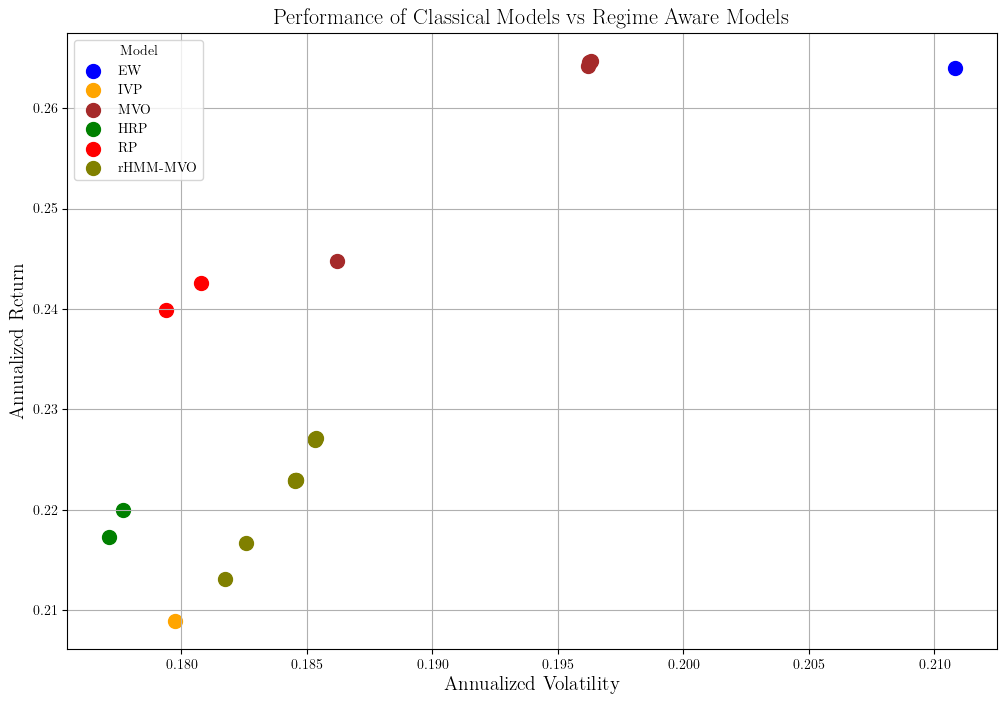

In [7]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs Regime Aware Models", fontsize=16)

for i, model in enumerate(tested_comparison_models):
    name = rHMM_MVO_comparison_models[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

for i, model in enumerate(tested_rHMM_MVO_models):
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="rHMM-MVO",
        color="olive",
        s=100,
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

x_lim = plt.gca().get_xlim()
y_lim = plt.gca().get_ylim()

plt.show()

Contrary to our expactation, the regime aware allocation models produced the same returns as the HRP variants, however they experienced larger volatility on the test period, thus performing worse on the historical data. Let us examine the result of the MC simulation: 

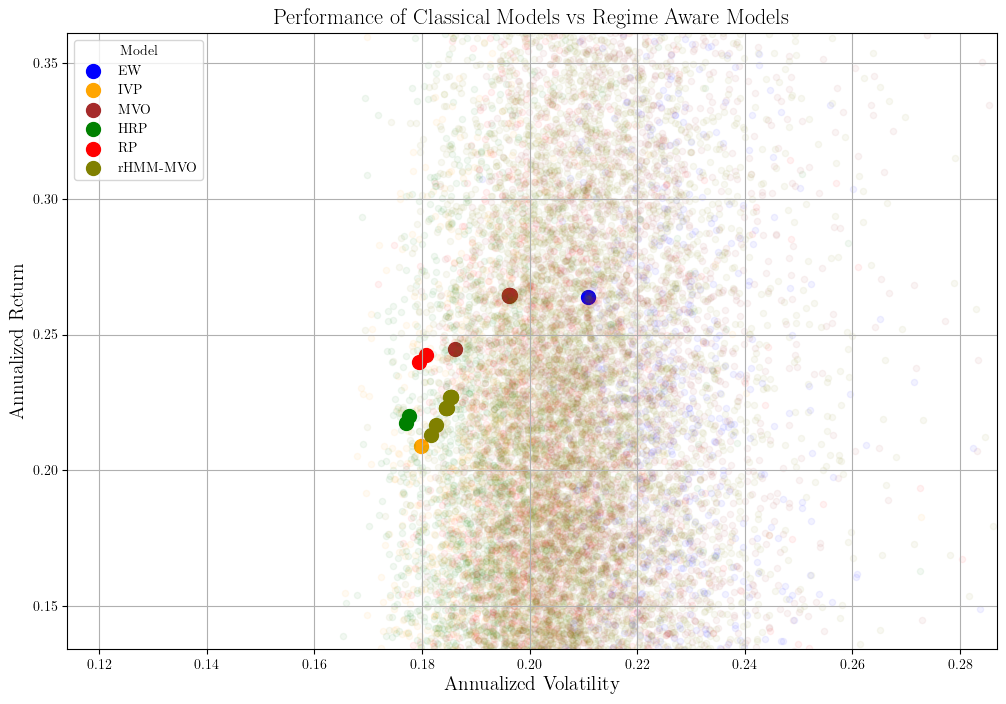

In [8]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs Regime Aware Models", fontsize=16)

for i, model in enumerate(tested_comparison_models):
    name = rHMM_MVO_comparison_models[i]["name"]

    with open(
        f"../data/rhmm_mvo_mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color=color,
    )

for i, model in enumerate(tested_rHMM_MVO_models):

    name = rHMM_MVO_models[i]["name"]

    with open(
        f"../data/rhmm_mvo_mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="rHMM-MVO",
        color="olive",
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color="olive",
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

mult = 0.35

x_lim_mc = (x_lim[0] * (1 - mult), x_lim[1] * (1 + mult))
y_lim_mc = (y_lim[0] * (1 - mult), y_lim[1] * (1 + mult))

plt.gca().set_xlim(x_lim_mc)
plt.gca().set_ylim(y_lim_mc)

plt.show()

Similarly as before we can see a consistently higher volatility in the MC simulations then in the historic backtest and a similarly large spread in the potential returns. To draw more definite conclusions we need to examine the performance metrics.

In [9]:
metrics_list = []
for i, model in enumerate(tested_comparison_models):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/rhmm_mvo_mc_metrics/{rHMM_MVO_comparison_models[i]["name"]}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = rHMM_MVO_comparison_models[i]["name"]
    metrics_list.append(metrics)


for i, model in enumerate(tested_rHMM_MVO_models):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/rhmm_mvo_mc_metrics/{rHMM_MVO_models[i]["name"]}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = rHMM_MVO_models[i]["name"]
    metrics_list.append(metrics)


df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

df_metrics = df_metrics.reindex(sorted(df_metrics.columns), axis=1)


if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics.round(4)

,Annualized Return,Annualized Return Max,Annualized Return Mean,Annualized Return Min,Annualized Return Std,Annualized Volatility,Annualized Volatility Max,Annualized Volatility Mean,Annualized Volatility Min,Annualized Volatility Std,...,Sortino Ratio,Sortino Ratio Max,Sortino Ratio Mean,Sortino Ratio Min,Sortino Ratio Std,VAR (95%),VAR (95%) Max,VAR (95%) Mean,VAR (95%) Min,VAR (95%) Std
Model,,,,,,,,,,,,,,,,,,,,,
EW,0.2640,0.6569,0.1709,-0.1711,0.1179,0.2108,0.3025,0.2259,0.1912,0.0121,...,1.4535,4.8102,1.1717,-0.9393,0.8287,0.0188,0.0241,0.0200,0.0165,0.0010
IVP,0.2089,0.4789,0.1537,-0.1337,0.0947,0.1797,0.2727,0.1902,0.1607,0.0118,...,1.2700,4.5441,1.2408,-0.9546,0.8054,0.0159,0.0197,0.0169,0.0143,0.0009
RP_FF_3_cov,0.2399,0.5368,0.1665,-0.1347,0.1025,0.1794,0.2885,0.2007,0.1724,0.0119,...,1.4756,4.8219,1.2868,-1.0177,0.8351,0.0152,0.0206,0.0178,0.0152,0.0009
HRP_historical_cov,0.2173,0.5227,0.1566,-0.1060,0.0980,0.1771,0.2592,0.1905,0.1652,0.0115,...,1.3481,4.6170,1.2677,-0.8712,0.8303,0.0149,0.0200,0.0170,0.0138,0.0009
RP_ledoit_wolf_cov,0.2426,0.5804,0.1649,-0.1065,0.1013,0.1808,0.2916,0.2029,0.1718,0.0122,...,1.4923,5.1102,1.2576,-0.8287,0.8092,0.0154,0.0209,0.0181,0.0152,0.0009
HRP_ledoit_wolf_cov,0.2200,0.4641,0.1580,-0.0913,0.0994,0.1777,0.2727,0.1930,0.1660,0.0118,...,1.3648,3.8203,1.2628,-0.6036,0.8277,0.0149,0.0208,0.0172,0.0149,0.0009
rHMM_MVO_historical_MVO_cov_historical_MVO_ret_historical_HRP_cov,0.2230,0.6034,0.1841,-0.0896,0.1071,0.1846,0.2657,0.2075,0.1739,0.0144,...,1.3448,5.5427,1.3806,-0.6271,0.8538,0.0162,0.0228,0.0183,0.0153,0.0012
rHMM_MVO_FF_3_MVO_cov_historical_MVO_ret_historical_HRP_cov,0.2229,0.5992,0.1896,-0.1377,0.1124,0.1846,0.3037,0.2085,0.1751,0.0154,...,1.3444,4.7307,1.4158,-0.8588,0.8808,0.0161,0.0230,0.0183,0.0154,0.0011
rHMM_MVO_Carhart_4_MVO_cov_historical_MVO_ret_historical_HRP_cov,0.2230,0.5466,0.1821,-0.1050,0.1066,0.1845,0.2660,0.2092,0.1746,0.0147,...,1.3447,4.5746,1.3551,-0.6984,0.8409,0.0161,0.0227,0.0184,0.0152,0.0011


In [10]:
df_metrics[
    [
        "Annualized Return",
        "Annualized Return Mean",
        "Annualized Volatility",
        "Annualized Volatility Mean",
        "Sharpe Ratio",
        "Sharpe Ratio Mean",
        "Max Drawdown",
        "Max Drawdown Mean",
    ]
].round(4)

,Annualized Return,Annualized Return Mean,Annualized Volatility,Annualized Volatility Mean,Sharpe Ratio,Sharpe Ratio Mean,Max Drawdown,Max Drawdown Mean
Model,,,,,,,,
EW,0.2640,0.1709,0.2108,0.2259,1.2525,0.7563,0.3317,0.3161
IVP,0.2089,0.1537,0.1797,0.1902,1.1622,0.8087,0.3008,0.2650
RP_FF_3_cov,0.2399,0.1665,0.1794,0.2007,1.3372,0.8290,0.3002,0.2750
HRP_historical_cov,0.2173,0.1566,0.1771,0.1905,1.2268,0.8214,0.3002,0.2602
RP_ledoit_wolf_cov,0.2426,0.1649,0.1808,0.2029,1.3419,0.8126,0.2999,0.2743
HRP_ledoit_wolf_cov,0.2200,0.1580,0.1777,0.1930,1.2384,0.8183,0.2997,0.2678
rHMM_MVO_historical_MVO_cov_historical_MVO_ret_historical_HRP_cov,0.2230,0.1841,0.1846,0.2075,1.2082,0.8869,0.2933,0.2758
rHMM_MVO_FF_3_MVO_cov_historical_MVO_ret_historical_HRP_cov,0.2229,0.1896,0.1846,0.2085,1.2080,0.9096,0.2933,0.2730
rHMM_MVO_Carhart_4_MVO_cov_historical_MVO_ret_historical_HRP_cov,0.2230,0.1821,0.1845,0.2092,1.2082,0.8711,0.2933,0.2788


If we look at the most important metrics, being the return, volatility, Sharpe ratio and the drawdown we can get to an interesting conclusion. Looking at purely the avarage return the models produced in the simulation the MVO models proove to be the best. Similarly only looking at the drawdown metric we will see the HRP models becoming the best. However the rHMM models that switch between the two allocation strategies are very close to the best models in all metrics while addressing the issue of the other. Thus we can conclude that the developed rHMM models are superior to pure MVO or HRP based allocation.

For any further investigation, based on the observed performance metrics we will be using the following models:

1. Equal weight portfolio

2. Inverse volatility weighted portfolio

3. Mean-variance portfolio with max sharpe objective, Carhart factor covariance estimator and historical return estimator

4. Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator

5. Mean-variance portfolio with max sharpe objective, Fama-French 5 factor covariance estimator and historical return estimator

6. Hierachical risk parity portfolio with with historical covariance estimator

7. Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator 

8. Risk parity portfolio with Fama-French 3 factor covariance estimator

9. Risk parity portfolio with Ledoit-Wolf covariance estimator

10. rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, exponentially weighted covariance estimator and historical return estimator and Risk parity portfolio with Ledoit-Wolf covariance estimator

11. rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator and Risk parity portfolio with historical covariance estimator

12. rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, Fama-French 3 factor covariance estimator and historical return estimator and Risk parity portfolio with Ledoit-Wolf covariance estimator


With this inplace let us make an out of sample benchmark both on historical data and MC simulation for the selected models on data between 2021 and 2025. This means retraining both the HMM model and the MC simulator on data between 2005 - 2020, then simulating the relevant number of paths.

In [11]:
from model_setup import choosen_classical_models_oos

In [12]:
stock_data_testing = pd.read_csv(
    "../data/raw/stock_data_testing.csv", index_col=0, parse_dates=True
)

In [13]:
oos_tested_models = []

In [14]:
for model in choosen_classical_models_oos:
    testing_model = model["class"](assets=stock_data_testing, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    oos_tested_models.append(testing_model)

In [15]:
index_data_testing = pd.read_csv(
    "../data/raw/index_data_testing.csv", index_col=0, parse_dates=True
)

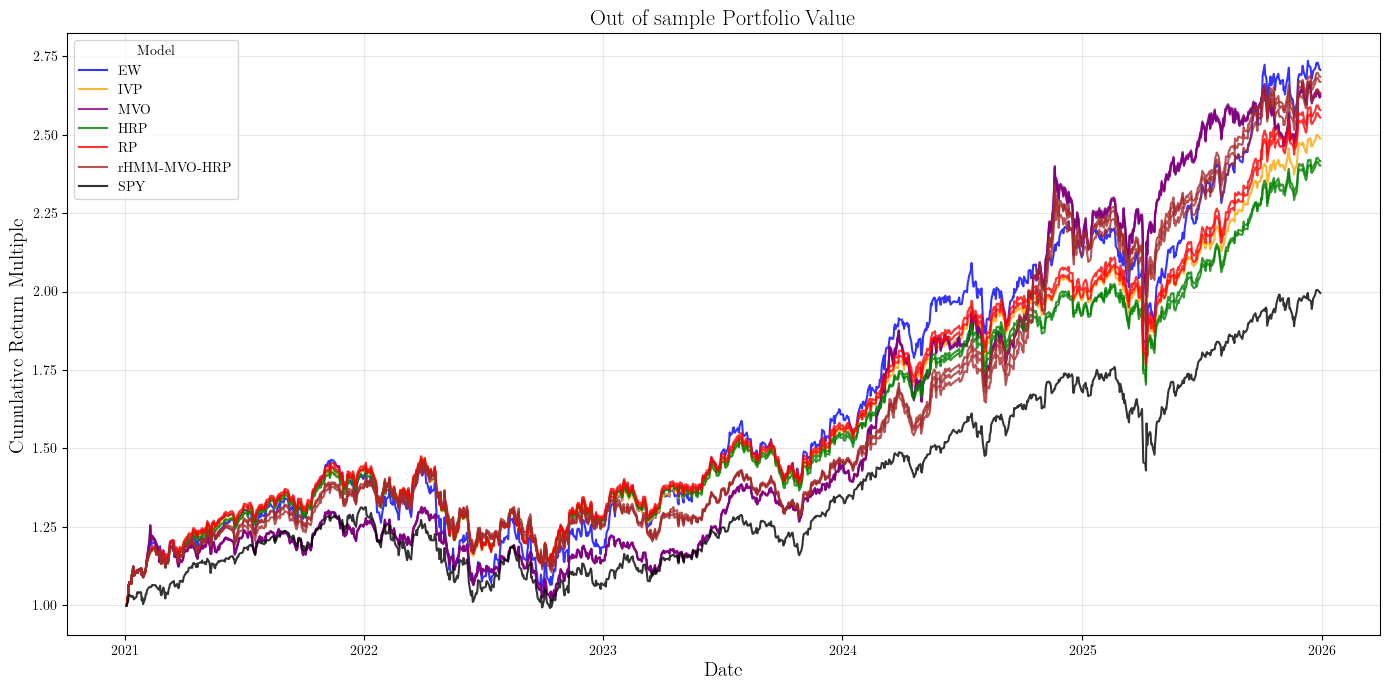

In [16]:
fig = plt.figure(figsize=(14, 7))
plt.title("Out of sample  Portfolio Value", fontsize=16)

for i, model in enumerate(oos_tested_models):
    name = choosen_classical_models_oos[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM-MVO-HRP"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "purple"
    elif name == "rHMM-MVO-HRP":
        color = "brown"

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data_testing.index,
        normalized_pv,
        label=name,
        alpha=0.8,
        linewidth=1.5,
        color=color,
    )


plt.plot(
    index_data_testing.index,
    index_data_testing["SPY"].values / index_data_testing["SPY"].values[0],
    label="SPY",
    alpha=0.8,
    linewidth=1.5,
    color="black",
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative Return Multiple", fontsize=14)
plt.grid(True, alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

plt.tight_layout()
plt.show()

In [17]:
metrics_list = []
for i, model in enumerate(oos_tested_models):

    metrics = model.performance_metrics.copy()

    metrics["Model"] = choosen_classical_models_oos[i]["name"]
    metrics_list.append(metrics)


spy_metrics = calculate_metrics(index_data_testing["SPY"].values)

spy_metrics["Model"] = "SPY"

metrics_list.append(spy_metrics)

df_metrics_oos = pd.DataFrame(metrics_list)
df_metrics_oos.set_index("Model", inplace=True)

df_metrics_oos = df_metrics_oos.reindex(sorted(df_metrics_oos.columns), axis=1)


if "Sharpe Ratio" in df_metrics.columns:
    df_metrics_oos.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics_oos.round(4)

,Annualized Return,Annualized Volatility,Calmar Ratio,ES (95%),Kurtosis,Max Drawdown,Sharpe Ratio,Skewness,Sortino Ratio,VAR (95%)
Model,,,,,,,,,,
EW,0.2218,0.2048,0.7970,0.0286,6.7575,0.2783,1.0834,0.0386,1.5928,0.0190
SPY,0.1490,0.1711,0.6081,0.0248,12.1023,0.2450,0.8707,0.2927,1.1947,0.0166
rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2184,0.1646,0.9046,0.0227,7.3990,0.2414,1.3266,0.2004,1.9731,0.0154
RP_ledoit_wolf_cov,0.2101,0.1580,0.8969,0.0224,7.8513,0.2342,1.3296,-0.0049,1.8747,0.0154
RP_FF_3_cov,0.2077,0.1562,0.8927,0.0221,7.8901,0.2327,1.3300,-0.0092,1.8705,0.0154
HRP_ledoit_wolf_cov,0.1928,0.1554,0.8351,0.0221,8.8583,0.2309,1.2408,0.0129,1.7262,0.0151
IVP,0.2013,0.1552,0.8788,0.0222,8.7307,0.2291,1.2977,0.0232,1.8036,0.0151
rHMM_MVO_FF_3_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2198,0.1676,0.9731,0.0224,7.8493,0.2259,1.3118,0.2999,1.9930,0.0160
MVO_max_sharpe_Carhart_4_cov_historical_ret,0.2148,0.1893,0.9509,0.0250,5.8734,0.2259,1.1350,0.2105,1.7871,0.0177


If we look at the out of sample tests result we can arrive at a very similar conclusion. While all models get a very similar performance, partly due to the strong bull market of the time period. However by the wealth curves we can see a much more consistent performance of the rHMM models compared to pure MVO based ones further emphasising the rHMM models advantage. We can also look at the MC results to further draw on this conclusion.

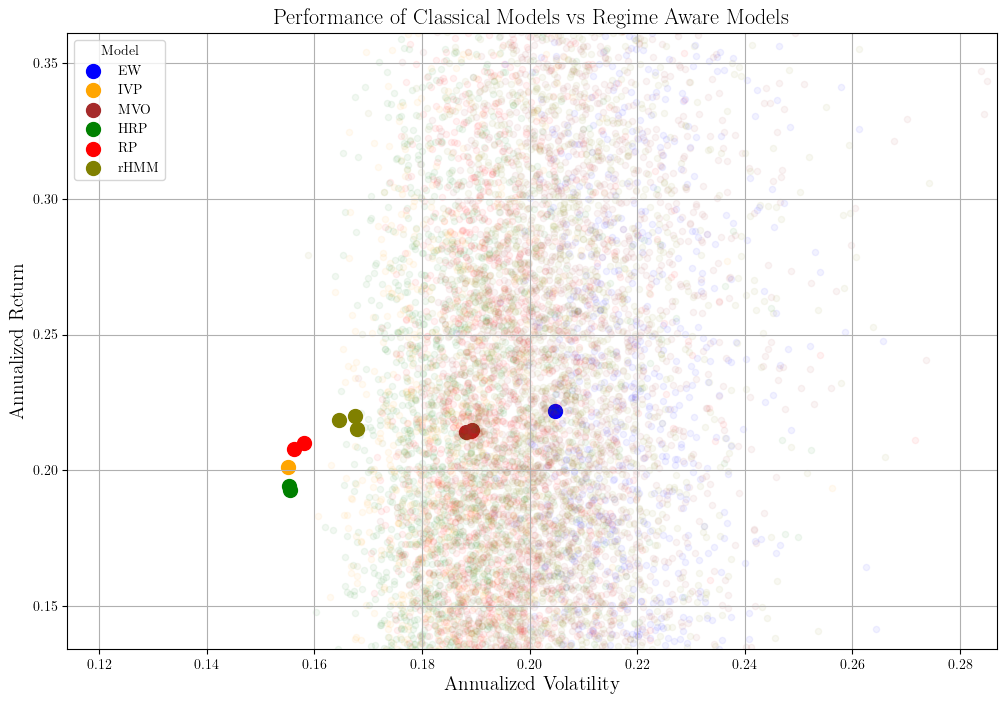

In [18]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs Regime Aware Models", fontsize=16)

for i, model in enumerate(oos_tested_models):
    name = choosen_classical_models_oos[i]["name"]

    with open(
        f"../data/oos_mc_metrics/{name}_static_skewed_t_oos_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    elif name == "rHMM":
        color = "olive"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color=color,
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

mult = 0.35

x_lim_mc = (x_lim[0] * (1 - mult), x_lim[1] * (1 + mult))
y_lim_mc = (y_lim[0] * (1 - mult), y_lim[1] * (1 + mult))

plt.gca().set_xlim(x_lim_mc)
plt.gca().set_ylim(y_lim_mc)

plt.show()

In [19]:
metrics_list = []
for i, model in enumerate(oos_tested_models):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/oos_mc_metrics/{choosen_classical_models_oos[i]["name"]}_static_skewed_t_oos_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = choosen_classical_models_oos[i]["name"]
    metrics_list.append(metrics)


df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

df_metrics = df_metrics.reindex(sorted(df_metrics.columns), axis=1)


if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics[
    [
        "Annualized Return",
        "Annualized Return Mean",
        "Annualized Volatility",
        "Annualized Volatility Mean",
        "Sharpe Ratio",
        "Sharpe Ratio Mean",
        "Max Drawdown",
        "Max Drawdown Mean",
    ]
].round(4)

,Annualized Return,Annualized Return Mean,Annualized Volatility,Annualized Volatility Mean,Sharpe Ratio,Sharpe Ratio Mean,Max Drawdown,Max Drawdown Mean
Model,,,,,,,,
EW,0.2218,0.2022,0.2048,0.2190,1.0834,0.9206,0.2783,0.2880
rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2184,0.2152,0.1646,0.2052,1.3266,1.0469,0.2414,0.2588
RP_ledoit_wolf_cov,0.2101,0.1882,0.1580,0.1946,1.3296,0.9668,0.2342,0.2522
RP_FF_3_cov,0.2077,0.1922,0.1562,0.1921,1.3300,0.9992,0.2327,0.2498
HRP_ledoit_wolf_cov,0.1928,0.1808,0.1554,0.1882,1.2408,0.9614,0.2309,0.2482
IVP,0.2013,0.1822,0.1552,0.1853,1.2977,0.9839,0.2291,0.2386
rHMM_MVO_FF_3_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2198,0.2179,0.1676,0.2047,1.3118,1.0645,0.2259,0.2589
MVO_max_sharpe_Carhart_4_cov_historical_ret,0.2148,0.2185,0.1893,0.2083,1.1350,1.0479,0.2259,0.2650
MVO_max_sharpe_historical_cov_historical_ret,0.2140,0.2194,0.1882,0.2082,1.1370,1.0529,0.2258,0.2640


We can arrive at a similar conclusion by examining the metrics of the MC simulation. Thus we can conclude that on both datasets the regime aware allocation portfolios performend better, thus are better than classical MVO or HRP.